# Propuesta 3
## Autor: Yasin Hanin Boukaddidi

El embedding usado es BioWordVec (intrínseco).

In [ ]:
!pip install gensim
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.0 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
from gensim.models.fasttext import load_facebook_model
ft = load_facebook_model('/content/drive/MyDrive/PLN/wiki.simple.bin')

In [ ]:
# si lo desgargas desde el ordenador
# ft = load_facebook_model('wiki.simple.bin')

In [ ]:
import pandas as pd

df = pd.read_csv('tcga_simple_train.csv')
print(df.columns)

text_list = df['text'].to_list()
tags = list(sorted(set(df['t'].to_list())))
print(tags)

Index(['patient_id', 'text', 't'], dtype='object')
['T1', 'T2', 'T3', 'T4']


# ¡Importante!
Cuando llegues y lo ejecutes seguramente te de error. Entonces, solamente reinicia la sesión, es debido a problemas de dependencia. Lo que has importado se guarda.

In [ ]:
%%capture
!pip install "numpy<2.0.0" "spacy==3.7.4" "scispacy==0.5.4"

# Elige el que necesites:
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_lg-0.5.4.tar.gz

In [ ]:
import spacy

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

nlp = spacy.load('en_core_sci_lg', disable=['parser', 'ner'])

def prepare_vocabulary(corpus):
    vocab = {}
    idx = 1
    # Usamos nlp.pipe para procesar en lotes (más rápido)
    for doc in nlp.pipe(corpus, batch_size=100, n_process=-1):
        tokens = [token.lemma_.lower() for token in doc
                  if not token.is_stop and not token.is_punct and token.text.isalnum()]
        for t in tokens:
            if t not in vocab:
                vocab[t] = idx
                idx += 1
    print(f'¡Vocabulario preparado! Tamaño: {len(vocab)}')
    return vocab

def prepare_sentences(corpus, word_index, maxlen):
    encoded_sentences = []
    # Usamos nlp.pipe también aquí para velocidad
    for doc in nlp.pipe(corpus, batch_size=100, n_process=-1):
        encoded_sentence = [word_index.get(token.text.lower(), 0) for token in doc]
        encoded_sentences.append(encoded_sentence)

    prepared = pad_sequences(encoded_sentences, maxlen=int(maxlen), padding='post', truncating='post')
    return prepared

Longitud máxima: 3862
Longitud media: 547.0


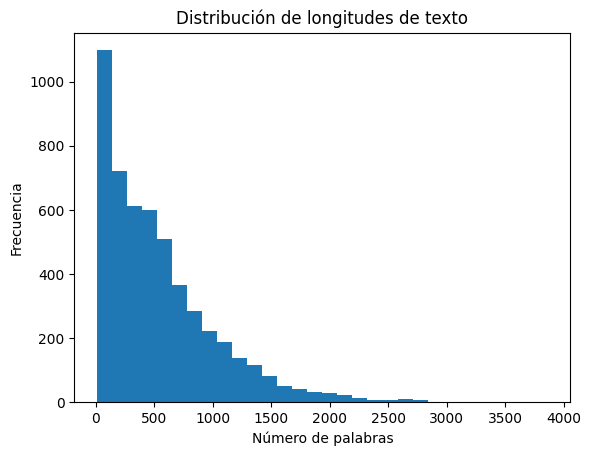

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Calculamos la longitud de cada texto (número de palabras)
sentence_lengths = [len(text.split()) for text in df['text']]

maxlen = np.mean(sentence_lengths)
maxlen = np.ceil(maxlen)

print(f'Longitud máxima: {max(sentence_lengths)}')
print(f'Longitud media: {maxlen}')

# Visualizamos la distribución
plt.hist(sentence_lengths, bins=30)
plt.title('Distribución de longitudes de texto')
plt.xlabel('Número de palabras')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
word_index = prepare_vocabulary(df['text'].to_list())

¡Vocabulario preparado! Tamaño: 25645


In [ ]:
prepared_sentences = prepare_sentences(df['text'].to_list(), word_index, maxlen)
print(f'Forma de la matriz: {prepared_sentences.shape}')
print("maxlen", maxlen)

Forma de la matriz: (5158, 547)
maxlen 547.0


In [ ]:
import numpy as np

# El vocabulario empieza en índice 1, el 0 es para padding
vocab_size = len(word_index) + 1
vector_size = ft.vector_size
embedding_matrix = np.zeros((vocab_size, vector_size))

for word, i in word_index.items():
    if word in ft.wv:
        embedding_matrix[i] = ft.wv[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(vector_size,))

print("Tamaño vocabulario (con padding):", vocab_size)
print("Dimensiones de la matriz:", embedding_matrix.shape)

Tamaño vocabulario (con padding): 25646
Dimensiones de la matriz: (25646, 300)


In [ ]:
from keras.models import Sequential
from keras.layers import GlobalAveragePooling1D, Dense, Embedding, Input, Dropout
import keras
import numpy as np

# Métrica F1 nativa
macro_f1_native = keras.metrics.F1Score(average='macro', name='macro_f1')


model = Sequential()
model.add(Input(shape=(int(maxlen),)))

model.add(Embedding(vocab_size, vector_size, weights=[embedding_matrix], trainable=True))

# Sustituimos Flatten por GlobalAveragePooling1D para reducir parámetros y evitar sobreajuste
model.add(GlobalAveragePooling1D())

# Añadimos Dropout para regularización
model.add(Dropout(0.5))

model.add(Dense(len(tags), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', macro_f1_native]
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 547, 300)       │     7,693,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 300)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         1,204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,695,004 (29.35 MB)

 Trainable params: 7,695,004 (29.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
import numpy as np

# 1. Preparar etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(df['t'])
y_categorical = to_categorical(y_encoded)

# 2. Convertir a arrays
X = np.array(prepared_sentences)
y = y_categorical

# 3. Dividir: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Entrenar el modelo
batch_size = 32
epochs = 20
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=batch_size,
    epochs=epochs
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3479 - loss: 1.3132 - macro_f1: 0.2398 - val_accuracy: 0.4341 - val_loss: 1.2507 - val_macro_f1: 0.2745
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4188 - loss: 1.2633 - macro_f1: 0.3166 - val_accuracy: 0.4974 - val_loss: 1.2090 - val_macro_f1: 0.3713
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4607 - loss: 1.2205 - macro_f1: 0.3564 - val_accuracy: 0.4509 - val_loss: 1.1747 - val_macro_f1: 0.3009
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4853 - loss: 1.1718 - macro_f1: 0.3821 - val_accuracy: 0.4755 - val_loss: 1.1330 - val_macro_f1: 0.3462
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5075 - loss: 1.1248 - macro_f1: 0.4036 - val_accuracy: 0.5052 - val_loss: 1.1019 - val_macro_f1: 0.3861
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5191 - loss: 1.0977 - macro_f1: 0.4187 - val_accuracy: 0.5439 - val_loss: 1.0820 - 

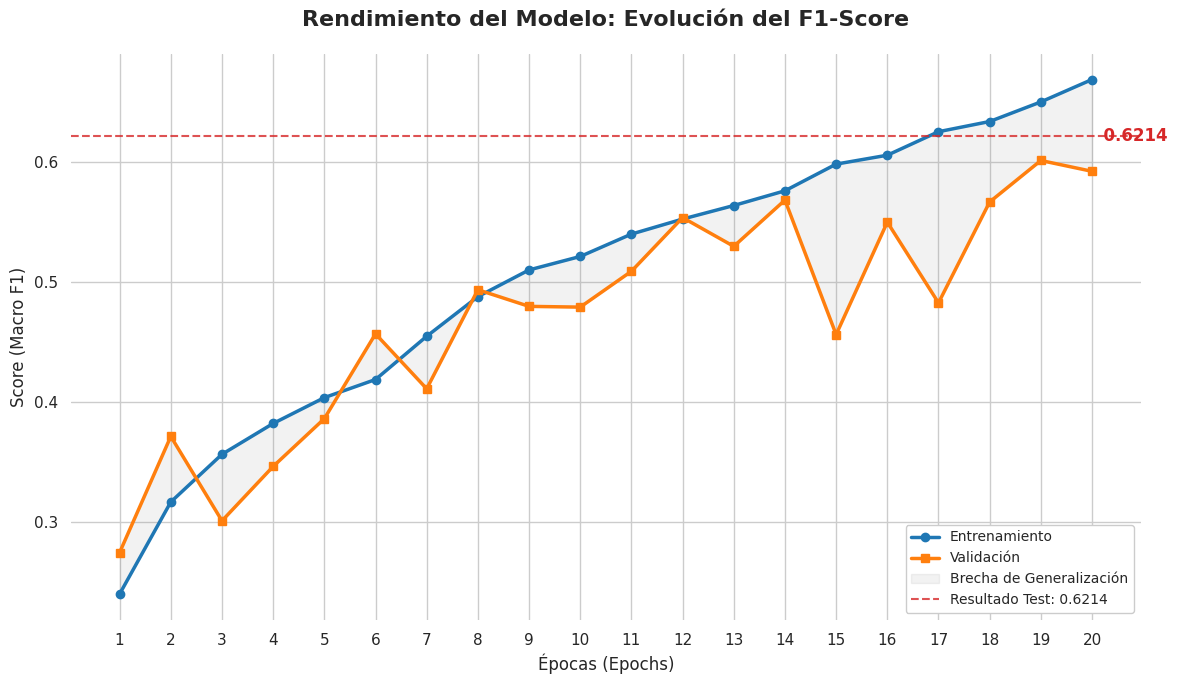


[INFO] Métrica evaluada: compile_metrics
[INFO] Precisión final en Test: 0.6214


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Evaluación final
test_results = model.evaluate(X_test, y_test, verbose=0)
metrics_dict = dict(zip(model.metrics_names, test_results))
f1_keys = [k for k in metrics_dict.keys() if 'f1' in k.lower()] or [k for k in metrics_dict.keys() if k not in ['loss', 'accuracy']]
f1_key = f1_keys[0] if f1_keys else 'accuracy'
test_f1 = metrics_dict[f1_key]

# 2. Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Obtener llaves del historial
h_key = [k for k in history.history.keys() if 'f1' in k.lower() and 'val' not in k][0]
v_key = [k for k in history.history.keys() if 'val' in k and ('f1' in k.lower() or h_key in k)][0]

train_vals = history.history[h_key]
val_vals = history.history[v_key]
epochs_range = range(1, len(train_vals) + 1)

# Dibujar líneas
plt.plot(epochs_range, train_vals, label='Entrenamiento', color='#1f77b4', linewidth=2.5, marker='o', markersize=6)
plt.plot(epochs_range, val_vals, label='Validación', color='#ff7f0e', linewidth=2.5, marker='s', markersize=6)

# Sombreado entre curvas (Visualización de Generalización)
plt.fill_between(epochs_range, train_vals, val_vals, color='gray', alpha=0.1, label='Brecha de Generalización')

# Línea de Test
plt.axhline(y=test_f1, color='#d62728', linestyle='--', alpha=0.8, label=f'Resultado Test: {test_f1:.4f}')

# Anotación del punto final de Test
plt.text(len(train_vals), test_f1, f'  {test_f1:.4f}', color='#d62728', fontweight='bold', va='center')

# Títulos y etiquetas
plt.title('Rendimiento del Modelo: Evolución del F1-Score', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Score (Macro F1)', fontsize=12)
plt.xticks(epochs_range)
plt.legend(frameon=True, facecolor='white', framealpha=1, fontsize=10)

# Eliminar bordes innecesarios
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

print(f'\n[INFO] Métrica evaluada: {f1_key}')
print(f'[INFO] Precisión final en Test: {test_f1:.4f}')

## Nueva Arquitectura: BiLSTM

En esta sección implementamos una red neuronal recurrente bidireccional. A diferencia del modelo anterior, las LSTMs pueden mantener memoria de largo plazo, y al ser bidireccionales, procesan el texto en ambas direcciones.

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input

model_bilstm = Sequential()
model_bilstm.add(Input(shape=(int(maxlen),)))

# Capa de Embedding (usando la misma matriz de pesos de FastText)
model_bilstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=vector_size,
    weights=[embedding_matrix],
    trainable=True
))

# Capa BiLSTM: 32 unidades por dirección (total 64)
model_bilstm.add(Bidirectional(LSTM(32)))

# Regularización
model_bilstm.add(Dropout(0.5))

# Capa de salida
model_bilstm.add(Dense(len(tags), activation='softmax'))

model_bilstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', macro_f1_native]
)

model_bilstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 547, 300)       │     7,693,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        85,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,779,308 (29.68 MB)

 Trainable params: 7,779,308 (29.68 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo BiLSTM
Ejecuta la siguiente celda para entrenar esta nueva versión.

In [ ]:
history_bilstm = model_bilstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=10
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.3465 - loss: 1.3141 - macro_f1: 0.3012 - val_accuracy: 0.3992 - val_loss: 1.2675 - val_macro_f1: 0.2462
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.4374 - loss: 1.2265 - macro_f1: 0.3545 - val_accuracy: 0.4703 - val_loss: 1.1761 - val_macro_f1: 0.4060
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5446 - loss: 1.0881 - macro_f1: 0.4876 - val_accuracy: 0.4793 - val_loss: 1.1434 - val_macro_f1: 0.4468
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6078 - loss: 0.9610 - macro_f1: 0.5777 - val_accuracy: 0.5013 - val_loss: 1.1385 - val_macro_f1: 0.4713
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.6709 - loss: 0.8360 - macro_f1: 0.6451 - val_accuracy: 0.4910 - val_loss: 1.2195 - val_macro_f1: 0.4567
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.7197 - loss: 0.7041 - macro_f1: 0.7062 - val_accuracy: 0.4819 - val_loss: 1.2

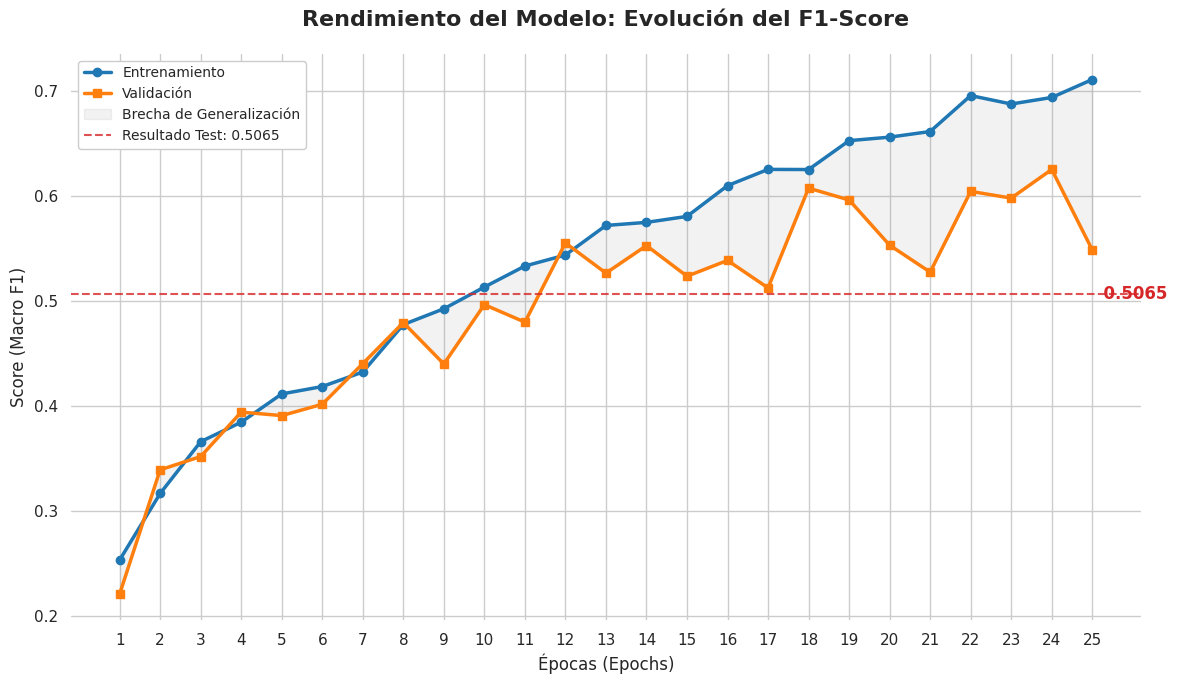


[INFO] Métrica evaluada: compile_metrics
[INFO] Precisión final en Test: 0.5065


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Evaluación final
test_results = model_bilstm.evaluate(X_test, y_test, verbose=0)
metrics_dict = dict(zip(model_bilstm.metrics_names, test_results))
f1_keys = [k for k in metrics_dict.keys() if 'f1' in k.lower()] or [k for k in metrics_dict.keys() if k not in ['loss', 'accuracy']]
f1_key = f1_keys[0] if f1_keys else 'accuracy'
test_f1 = metrics_dict[f1_key]

# 2. Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Obtener llaves del historial
h_key = [k for k in history.history.keys() if 'f1' in k.lower() and 'val' not in k][0]
v_key = [k for k in history.history.keys() if 'val' in k and ('f1' in k.lower() or h_key in k)][0]

train_vals = history.history[h_key]
val_vals = history.history[v_key]
epochs_range = range(1, len(train_vals) + 1)

# Dibujar líneas
plt.plot(epochs_range, train_vals, label='Entrenamiento', color='#1f77b4', linewidth=2.5, marker='o', markersize=6)
plt.plot(epochs_range, val_vals, label='Validación', color='#ff7f0e', linewidth=2.5, marker='s', markersize=6)

# Sombreado entre curvas (Visualización de Generalización)
plt.fill_between(epochs_range, train_vals, val_vals, color='gray', alpha=0.1, label='Brecha de Generalización')

# Línea de Test
plt.axhline(y=test_f1, color='#d62728', linestyle='--', alpha=0.8, label=f'Resultado Test: {test_f1:.4f}')

# Anotación del punto final de Test
plt.text(len(train_vals), test_f1, f'  {test_f1:.4f}', color='#d62728', fontweight='bold', va='center')

# Títulos y etiquetas
plt.title('Rendimiento del Modelo: Evolución del F1-Score', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Score (Macro F1)', fontsize=12)
plt.xticks(epochs_range)
plt.legend(frameon=True, facecolor='white', framealpha=1, fontsize=10)

# Eliminar bordes innecesarios
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

print(f'\n[INFO] Métrica evaluada: {f1_key}')
print(f'[INFO] Precisión final en Test: {test_f1:.4f}')

## 📊 Resumen de Resultados y Conclusiones

### 1. Comparación de Modelos
| Modelo | Test F1-Score (Macro) | Observaciones |
| :--- | :--- | :--- |
| **Secuencial (Base)** | **~0.5827** | Mejor rendimiento inicial. La promediación global ayuda a evitar ruidos en textos largos. |
| **BiLSTM (Inicial)** | **~0.4716** | Rendimiento inferior. Sufre de sobreajuste y dificultad para extraer patrones en secuencias de >500 tokens con embeddings fijos. |

### 2. Análisis de Causas
*   **Longitud de las Secuencias**: Con una media de 547 palabras, las LSTMs tienden a olvidar información del inicio de la frase si no están perfectamente ajustadas, o se ven afectadas por el ruido de secciones irrelevantes del reporte médico.
*   **Embeddings Estáticos**: Al congelar los pesos de FastText (`trainable=False`), el modelo BiLSTM no pudo adaptar los vectores a los tecnicismos específicos de este dataset de patología.
*   **Complejidad vs. Datos**: Para el volumen de datos actual, una red recurrente compleja tiene demasiados parámetros, lo que facilita que memorice el ruido del entrenamiento en lugar de generalizar los patrones de las etiquetas T1-T4.

### 3. Siguientes Pasos Recomendados
1. **Descongelar Embeddings**: Entrenar la capa de embedding junto con la red.
2. **Uso de Attention**: Implementar una capa de Atención para que el modelo ignore las partes genéricas del texto y se enfoque en las palabras clave del diagnóstico.
3. **Ajuste de Hiperparámetros**: Reducir el Dropout y probar optimizadores con *learning rate* más bajo.